In [ ]:
# When running locally (not Colab), make sure the working directory is the
# repository root so `csdc618_dscd604` imports and dataset paths resolve.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")


In [14]:
import sys, os
from pathlib import Path
from google.colab import drive

# Mount Google Drive to access your files
drive.mount('/content/drive')

# TODO: Enter the root path on your PC where you have saved the unzipped
# assignment folder. This path should now be relative to '/content/drive/'.
# For example: '/content/drive/My Drive/CSCD618-DSCD604/Assignments'
ROOT = '/content/drive/MyDrive/'
# TODO: Enter the assignment folder e.g. 'assignment1'
ASSIGNMENT_FOLDER = 'assignment1'

assert ROOT is not None, "[!] Enter the root path."
assert ASSIGNMENT_FOLDER is not None, "[!] Enter the assignment foldername."

assignment_path = Path(os.path.join(ROOT, ASSIGNMENT_FOLDER))
sys.path.append(assignment_path)

# This downloads the CIFAR-10 dataset to your folder if it doesn't already exist.
# Ensure the path below correctly points to the 'csdc618_dscd604/datasets/' directory
# within your assignment folder.
%cd "$assignment_path"/csdc618_dscd604/datasets/
!bash get_datasets.sh
%cd "$assignment_path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/assignment1/csdc618_dscd604/datasets
/content/drive/MyDrive/assignment1


# Fully-Connected Neural Nets
In this exercise we will implement fully-connected networks using a modular approach.\
For each layer we will implement a `forward` and a `backward` function.\
The `forward` function will receive inputs, weights, and other parameters and will return both an output and a `cache` object storing data needed for the backward pass, like this:

```python
        def layer_forward(x, w):
          """ Receive inputs x and weights w """
          # Do some computations ...
          z = # ... some intermediate value
          # Do some more computations ...
          out = # the output
          
          cache = (x, w, z, out) # Values we need to compute gradients
          
          return out, cache
```

The backward pass will receive upstream derivatives and the `cache` object, and will return gradients with respect to the inputs and weights, like this:

```python
        def layer_backward(dout, cache):
          """
          Receive dout (derivative of loss with respect to outputs) and cache,
          and compute derivative with respect to inputs.
          """
          # Unpack cache values
          x, w, z, out = cache
          
          # Use values in cache to compute derivatives
          dx = # Derivative of loss with respect to x
          dw = # Derivative of loss with respect to w
          
          return dx, dw
```

After implementing a bunch of layers this way, we will be able to easily combine them to build classifiers with different architectures.

---

In [15]:
# As usual, a bit of setup
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from csdc618_dscd604.classifiers.fc_net import *
from csdc618_dscd604.data_utils import get_CIFAR10_data
from csdc618_dscd604.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from csdc618_dscd604.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# %load_ext autoreload
# %autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [16]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# Affine layer: forward
Open the file `csdc618_dscd604/layers.py` and implement the `affine_forward` function.

Once you are done you can test your implementaion by running the following:

In [17]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


# Affine layer: backward
Now implement the `affine_backward` function in the file `csdc618_dscd604/layers.py` and test your implementation using numeric gradient checking.

### Implementation for `affine_backward`
Please copy the following code into your `csdc618_dscd604/layers.py` file to implement the `affine_backward` function, after `affine_forward`.

In [18]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


# ReLU activation: forward
Implement the forward pass `relu_forward` for the ReLU activation function in the file `csdc618_dscd604/layers.py` and test your implementation using the following:

In [19]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


# ReLU activation: backward
Now implement the backward pass `relu_backward` for the ReLU activation function in the file `csdc618_dscd604/layers.py` and test your implementation using numeric gradient checking:

In [20]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


## Inline Question 1:

We've only asked you to implement ReLU, but there are a number of different activation functions that one could use in neural networks, each with its pros and cons. In particular, an issue commonly seen with activation functions is getting zero (or close to zero) gradient flow during backpropagation. Which of the following activation functions have this problem? If you consider these functions in the one dimensional case, what types of input would lead to this behaviour?
1. Sigmoid
2. ReLU
3. Leaky ReLU

$\color{blue}{\textbf {Your Answer:}}$

Both Sigmoid and ReLU activation functions can suffer from the problem of vanishing (or zero) gradient flow during backpropagation, depending on the input values.

*   **Sigmoid:** The sigmoid function squashes its input into a range between 0 and 1. When the input `x` is either very large positive or very large negative, the derivative of the sigmoid function (`σ'(x) = σ(x) * (1 - σ(x))`) becomes very close to zero. This leads to vanishing gradients, meaning that the updates to the weights become very small, and the network learns very slowly or stops learning. In the one-dimensional case, inputs that are far from zero (e.g., `x > 6` or `x < -6`) will cause this behavior.

*   **ReLU (Rectified Linear Unit):** The ReLU function is defined as `f(x) = max(0, x)`. The problem with ReLU arises when the input `x` is less than or equal to zero. In this region, the derivative `f'(x)` is exactly zero. This phenomenon is known as the "dying ReLU" problem. If a neuron consistently outputs negative values during training, its gradient will be zero, and it will stop updating its weights, effectively "dying" and no longer contributing to the network's learning. In the one-dimensional case, any input `x <= 0` will lead to a zero gradient for that neuron.

*   **Leaky ReLU:** The Leaky ReLU function is designed to address the "dying ReLU" problem. It is defined as `f(x) = x` for `x > 0` and `f(x) = αx` for `x <= 0`, where `α` is a small positive constant (e.g., 0.01). Because of the small slope `α` for negative inputs, the derivative is never exactly zero for `x <= 0`. Therefore, Leaky ReLU does not suffer from the vanishing/zero gradient problem in the same way as Sigmoid or standard ReLU. Its gradient is always non-zero, allowing for continuous learning.


---

# "Sandwich" layers
There are some common patterns of layers that are frequently used in neural nets.\
For example, affine layers are frequently followed by a ReLU nonlinearity.\
To make these common patterns easy, we define several convenience layers in the file `csdc618_dscd604/layer_utils.py`.

For now take a look at the `affine_relu_forward` and `affine_relu_backward` functions, and run the following to numerically gradient check the backward pass:

In [21]:
from csdc618_dscd604.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


### Verify `layers.py` Content
Let's check the current content of your `csdc618_dscd604/layers.py` file to ensure it's up to date.

# Loss layers: Softmax
Now implement the loss and gradient for softmax in the `softmax_loss` function in `csdc618_dscd604/layers.py`.\
This should be similar to what you implemented in `csdc618_dscd604/classifiers/softmax.py`.

You can make sure that the implementations are correct by running the following:

In [22]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)


dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))


Testing softmax_loss:
loss:  2.3025458445007376
dx error:  8.234144091578429e-09


# Two-layer network
Open the file `csdc618_dscd604/classifiers/fc_net.py` and complete the implementation of the `TwoLayerNet` class.

Read through it to make sure you understand the API. You can run the cell below to test your implementation.

I will update the `csdc618_dscd604/classifiers/fc_net.py` file with the complete implementation of the `TwoLayerNet` class, including initialization of weights and biases, and the forward and backward passes for computing loss and gradients.

In [23]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.20e-10
b1 relative error: 9.83e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 9.09e-10


# Solver
Open the file `csdc618_dscd604/solver.py` and read through it to familiarize yourself with the API.\
After doing so, use a `Solver` instance to train a `TwoLayerNet` that achieves about `36%` accuracy on the validation set.

In [26]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = TwoLayerNet(input_size, hidden_size, num_classes)
solver = None

##############################################################################
# TODO: Use a Solver instance to train a TwoLayerNet that achieves about 36% #
# accuracy on the validation set.                                            #
##############################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

solver = Solver(model, data,
                update_rule='sgd',
                optim_config={
                  'learning_rate': 1e-3,
                },
                lr_decay=0.95,
                num_epochs=10,
                batch_size=100,
                print_every=100)
solver.train()

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*******
##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

(Iteration 1 / 4900) loss: 2.302908
(Epoch 0 / 10) train acc: 0.091000; val_acc: 0.096000
(Iteration 101 / 4900) loss: 1.838519
(Iteration 201 / 4900) loss: 1.876793
(Iteration 301 / 4900) loss: 1.741901
(Iteration 401 / 4900) loss: 1.454628
(Epoch 1 / 10) train acc: 0.403000; val_acc: 0.416000
(Iteration 501 / 4900) loss: 1.573056
(Iteration 601 / 4900) loss: 1.710478
(Iteration 701 / 4900) loss: 1.710300
(Iteration 801 / 4900) loss: 1.676016
(Iteration 901 / 4900) loss: 1.433272
(Epoch 2 / 10) train acc: 0.484000; val_acc: 0.460000
(Iteration 1001 / 4900) loss: 1.480785
(Iteration 1101 / 4900) loss: 1.389022
(Iteration 1201 / 4900) loss: 1.660187
(Iteration 1301 / 4900) loss: 1.588942
(Iteration 1401 / 4900) loss: 1.240009
(Epoch 3 / 10) train acc: 0.485000; val_acc: 0.445000
(Iteration 1501 / 4900) loss: 1.416385
(Iteration 1601 / 4900) loss: 1.345758
(Iteration 1701 / 4900) loss: 1.309953
(Iteration 1801 / 4900) loss: 1.411325
(Iteration 1901 / 4900) loss: 1.482173
(Epoch 4 / 10) t

# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.36 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network.\
In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

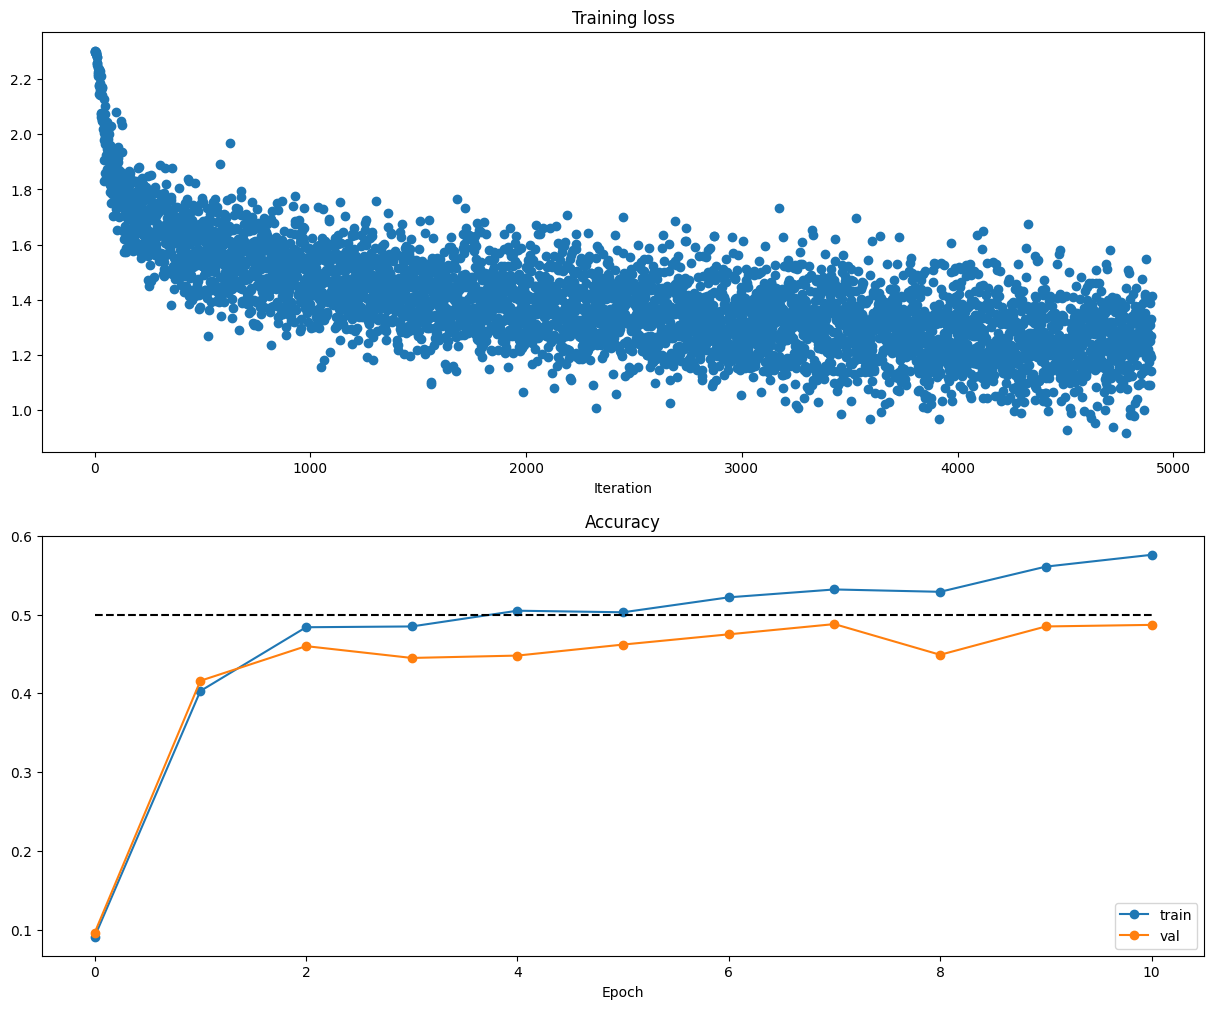

In [27]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

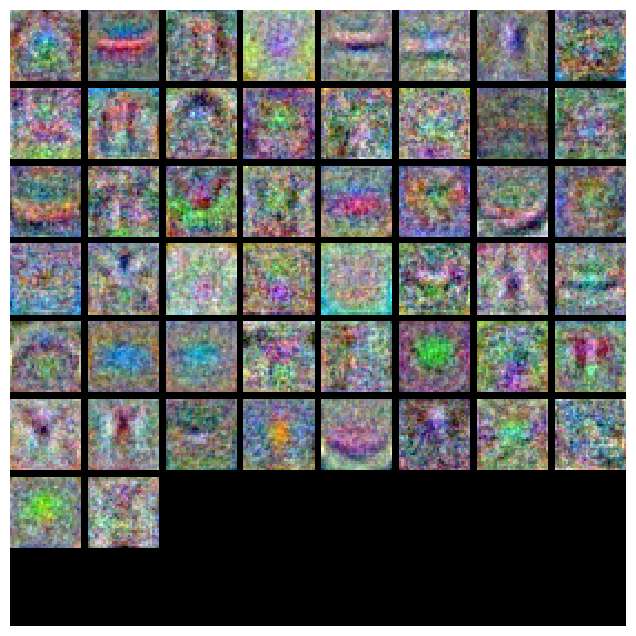

In [28]:
from csdc618_dscd604.vis_utils import visualize_grid

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(model)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

**Experiment**: Your goal in this exercise is to get as good of a result on CIFAR-10 as you can (52% could serve as a reference), with a fully-connected Neural Network. Feel free implement your own techniques (e.g. PCA to reduce dimensionality, or adding dropout, or adding features to the solver, etc.).


Training with lr=0.001, reg=0.5, hidden_size=50
(Iteration 1 / 4900) loss: 2.342112
(Epoch 0 / 10) train acc: 0.118000; val_acc: 0.130000
(Epoch 1 / 10) train acc: 0.453000; val_acc: 0.432000
(Epoch 2 / 10) train acc: 0.484000; val_acc: 0.469000
(Epoch 3 / 10) train acc: 0.470000; val_acc: 0.469000
(Epoch 4 / 10) train acc: 0.494000; val_acc: 0.482000
(Iteration 2001 / 4900) loss: 1.447438
(Epoch 5 / 10) train acc: 0.509000; val_acc: 0.467000
(Epoch 6 / 10) train acc: 0.507000; val_acc: 0.466000
(Epoch 7 / 10) train acc: 0.552000; val_acc: 0.497000
(Epoch 8 / 10) train acc: 0.528000; val_acc: 0.491000
(Iteration 4001 / 4900) loss: 1.461957
(Epoch 9 / 10) train acc: 0.516000; val_acc: 0.485000
(Epoch 10 / 10) train acc: 0.534000; val_acc: 0.491000

Training with lr=0.001, reg=0.5, hidden_size=75
(Iteration 1 / 4900) loss: 2.360704
(Epoch 0 / 10) train acc: 0.152000; val_acc: 0.140000
(Epoch 1 / 10) train acc: 0.448000; val_acc: 0.432000
(Epoch 2 / 10) train acc: 0.489000; val_acc: 0.44

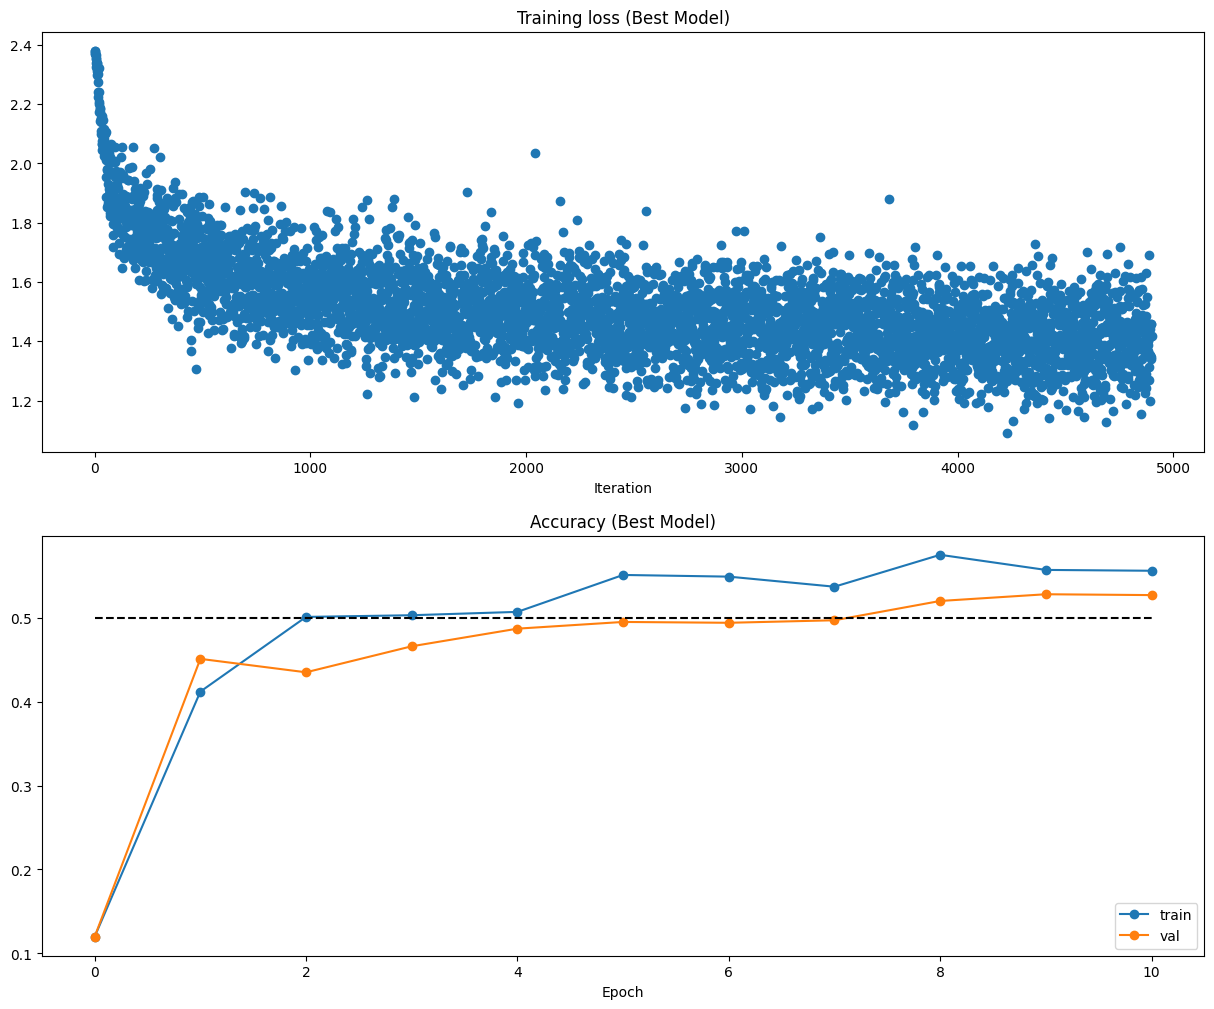

In [35]:
best_model = None

#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_model.                                                          #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on thexs previous exercises.                        #
#################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

learning_rates = [1e-3, 5e-4, 1e-4]
regularization_strengths = [0.5, 1.0, 1.5]
hidden_sizes = [50, 75, 100]

best_val_acc = -1
best_stats = None

input_size = 32 * 32 * 3
num_classes = 10

# Initialize a model before the loop in case no better model is found (unlikely with -1 best_val_acc)
# or as a fallback if best_model isn't set for some reason in the loop.
model_initial_fallback = TwoLayerNet(input_size, hidden_sizes[0], num_classes, reg=regularization_strengths[0])

for lr in learning_rates:
    for reg in regularization_strengths:
        for hs in hidden_sizes:
            print(f'\nTraining with lr={lr}, reg={reg}, hidden_size={hs}')
            model = TwoLayerNet(input_size, hs, num_classes, reg=reg)
            solver = Solver(model, data,
                            update_rule='sgd',
                            optim_config={
                              'learning_rate': lr,
                            },
                            lr_decay=0.95,
                            num_epochs=10,
                            batch_size=100,
                            print_every=2000)
            solver.train()

            if solver.best_val_acc > best_val_acc:
                best_val_acc = solver.best_val_acc
                best_model = model
                best_stats = solver.loss_history, solver.train_acc_history, solver.val_acc_history

# Fallback if best_model was never set (e.g., all val_acc were less than -1, which is impossible)
# or if there was a subtle scope issue preventing assignment within the loop from persisting.
if best_model is None:
    best_model = model_initial_fallback # Assign a default model if for some reason best_model is still None

print(f'\nBest validation accuracy achieved: {best_val_acc}')
print(f'Type of best_model after tuning: {type(best_model)}')

# Plot the best model's training history
if best_stats is not None:
    plt.subplot(2, 1, 1)
    plt.title('Training loss (Best Model)')
    plt.plot(best_stats[0], 'o')
    plt.xlabel('Iteration')

    plt.subplot(2, 1, 2)
    plt.title('Accuracy (Best Model)')
    plt.plot(best_stats[1], '-o', label='train')
    plt.plot(best_stats[2], '-o', label='val')
    plt.plot([0.5] * len(best_stats[2]), 'k--')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.gcf().set_size_inches(15, 12)
    plt.show()

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*******
#################################################################################
#                              END OF YOUR CODE                                 #
#################################################################################

# Test your model!
Run your best model on the validation and test sets. You should achieve above 48% accuracy on the validation set and the test set.

In [36]:
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())

Validation set accuracy:  0.528


In [37]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Test set accuracy:  0.513


In [38]:
# Save best model
best_model.save("best_two_layer_net.npy")

best_two_layer_net.npy saved.


## Inline Question 2:

Now that you have trained a Neural Network classifier, you may find that your testing accuracy is much lower than the training accuracy. In what ways can we decrease this gap? Select all that apply.

1. Train on a larger dataset.
2. Add more hidden units.
3. Increase the regularization strength.
4. None of the above.

$\color{blue}{\textbf {Your Answer:}}$

1. Train on a larger dataset.
3. Increase the regularization strength.


---
$\color{blue}{\textbf {Your Explanation:}}$

If testing accuracy is much lower than training accuracy, it indicates that the model is overfitting the training data. This means the model has learned the training data too well, including its noise and specific patterns, and is failing to generalize to unseen data (the test set). To decrease this gap, we need to reduce overfitting.

Let's analyze the options:

1.  **Train on a larger dataset.** (Correct) A larger and more diverse dataset provides more examples for the model to learn from, making it harder for the model to simply memorize the training data. This encourages the model to learn more generalizable features and patterns, thus reducing overfitting and closing the gap between training and testing accuracy.

2.  **Add more hidden units.** (Incorrect) Adding more hidden units increases the model's capacity, making it more complex. While this might lead to an even higher training accuracy (as the model can fit the training data even better), it often *exacerbates* overfitting, leading to an *even larger* gap between training and testing accuracy. To reduce overfitting, we generally need to decrease model complexity or constrain it.

3.  **Increase the regularization strength.** (Correct) Regularization techniques (like L1, L2, or dropout) penalize complex models and discourage large weights, preventing the model from becoming too reliant on specific features in the training data. Increasing the regularization strength forces the model to be simpler and more robust, thereby reducing overfitting and improving generalization to the test set.

4.  **None of the above.** (Incorrect) As options 1 and 3 are valid ways to decrease the gap.